# 01 — Direct narrow escape problem

This notebook validates the **direct geometric solver** (`NaiveNarrowEscape`) and then uses it to recover the characteristic increase of the mean first-passage time when a boundary window becomes narrow.

The notebook has three deliverables:

1. A one-dimensional validation against the exact mean exit time from an interval.
2. A two-dimensional parameter sweep in the unit disk with independent random streams and confidence intervals.
3. A representative trajectory suitable for a report figure.

`epsilon` denotes the vertical chord length of a single absorbing window centred at `(1, 0)` on the unit circle. All other boundary points are reflective.


## Environment

Run the notebook from the repository root or from `notebooks/` after installing the project with:

```bash
python -m pip install -e ".[notebook]"
```

The simulation and plotting APIs are kept separate: simulations return `NarrowEscapeResult` objects, while this notebook composes the report figures explicitly.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from scipy import stats

from stage_escape import BrownianMotion, Escape, NaiveNarrowEscape, Surface

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


In [2]:
# Reproducible execution profile.
QUICK_RUN = True
FORCE_RECOMPUTE = False
N_JOBS = -1
BASE_SEED = 20260717

# Physical and numerical parameters.
D = 1.0
DELTA_T_1D = 1.0e-3
DELTA_T_2D = 5.0e-4
DEPOSITION_STRIDE = 100

if QUICK_RUN:
    HALF_LENGTHS = np.linspace(0.5, 3.0, 11)
    EPSILONS = np.geomspace(0.50, 0.04, 9)
    N_REPLICATES_1D = 40
    N_REPLICATES_2D = 32
    MAX_STEPS_1D = 250_000
    MAX_STEPS_2D = 500_000
else:
    HALF_LENGTHS = np.linspace(0.4, 4.0, 19)
    EPSILONS = np.geomspace(0.50, 0.015, 15)
    N_REPLICATES_1D = 200
    N_REPLICATES_2D = 150
    MAX_STEPS_1D = 1_500_000
    MAX_STEPS_2D = 3_000_000

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_DIR = REPO_ROOT / "artifacts"
CACHE_DIR = ARTIFACT_DIR / "notebook_cache"
FIGURE_DIR = ARTIFACT_DIR / "figures" / "01_direct_narrow_escape"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PROFILE = "quick" if QUICK_RUN else "full"


## Reproducibility and statistical helpers

A different deterministic seed is generated for every parameter–replicate pair. This avoids the accidental reuse of the same Brownian trajectory across nominally independent repetitions.

Only escaped trajectories enter the conditional mean. The escape fraction is reported separately so that censoring by `max_steps` is visible rather than silently discarded.


In [3]:
def spawned_seeds(base_seed: int, count: int) -> list[int]:
    sequence = np.random.SeedSequence(base_seed)
    return [int(child.generate_state(1, dtype=np.uint32)[0]) for child in sequence.spawn(count)]


def confidence_summary(values, confidence: float = 0.95) -> dict[str, float]:
    sample = np.asarray(values, dtype=float)
    sample = sample[np.isfinite(sample)]
    n = sample.size
    if n == 0:
        return {"n": 0, "mean": np.nan, "std": np.nan, "sem": np.nan, "ci": np.nan}
    mean = float(np.mean(sample))
    if n == 1:
        return {"n": 1, "mean": mean, "std": np.nan, "sem": np.nan, "ci": np.nan}
    std = float(np.std(sample, ddof=1))
    sem = std / np.sqrt(n)
    ci = float(stats.t.ppf(0.5 + confidence / 2.0, df=n - 1) * sem)
    return {"n": int(n), "mean": mean, "std": std, "sem": sem, "ci": ci}


def summarize_records(records: list[dict], parameter: str) -> list[dict]:
    summary = []
    for value in sorted({float(record[parameter]) for record in records}):
        group = [record for record in records if np.isclose(record[parameter], value)]
        escaped_times = [record["escape_time"] for record in group if record["escaped"]]
        statistics = confidence_summary(escaped_times)
        summary.append(
            {
                parameter: value,
                **statistics,
                "attempts": len(group),
                "escape_fraction": float(np.mean([record["escaped"] for record in group])),
                "mean_rejection_fraction": float(
                    np.mean([record["rejection_fraction"] for record in group])
                ),
            }
        )
    return summary


def print_summary(summary: list[dict], parameter: str) -> None:
    header = f"{parameter:>12} | {'mean':>10} | {'95% CI':>10} | {'escaped':>9} | {'reject.':>9}"
    print(header)
    print("-" * len(header))
    for row in summary:
        escaped = f"{row['n']}/{row['attempts']}"
        print(
            f"{row[parameter]:12.5g} | {row['mean']:10.5g} | {row['ci']:10.3g} | "
            f"{escaped:>9} | {row['mean_rejection_fraction']:9.3f}"
        )


def load_or_compute(cache_path: Path, compute) -> list[dict]:
    if cache_path.exists() and not FORCE_RECOMPUTE:
        with cache_path.open("r", encoding="utf-8") as stream:
            return json.load(stream)
    records = compute()
    with cache_path.open("w", encoding="utf-8") as stream:
        json.dump(records, stream, indent=2)
    return records


def save_figure(fig, filename: str) -> None:
    fig.savefig(FIGURE_DIR / filename, bbox_inches="tight")


## 1. One-dimensional validation

For Brownian motion with generator `D Delta`, started at the centre of the interval `[-L, L]`, the exact mean first exit time is

$[
\mathbb{E}[\tau_L] = \frac{L^2}{2D}.
]$

This section checks both the expected quadratic dependence and the absolute normalization of the implementation.


In [4]:
def simulate_interval_exit(half_length: float, seed: int) -> dict:
    motion = BrownianMotion(
        deposition_stride=DEPOSITION_STRIDE,
        delta_t=DELTA_T_1D,
        dimension=1,
        D=D,
        initial_position=np.array([0.0]),
        seed=seed,
    )
    interval = Surface(
        "symmetric interval",
        [lambda point, L=half_length: point[0] ** 2 - L**2],
    )
    absorbing_boundary = Escape([lambda point: True])
    result = NaiveNarrowEscape(motion, interval, [absorbing_boundary]).run(
        max_steps=MAX_STEPS_1D
    )
    return {
        "half_length": float(half_length),
        "seed": int(seed),
        "escaped": bool(result.escaped),
        "escape_time": None if result.escape_time is None else float(result.escape_time),
        "attempted_steps": int(result.attempted_steps),
        "rejection_fraction": float(result.rejected_steps / max(result.attempted_steps, 1)),
    }


def compute_interval_sweep() -> list[dict]:
    tasks = [(float(L), replicate) for L in HALF_LENGTHS for replicate in range(N_REPLICATES_1D)]
    seeds = spawned_seeds(BASE_SEED, len(tasks))
    return Parallel(n_jobs=N_JOBS)(
        delayed(simulate_interval_exit)(L, seed)
        for (L, _), seed in zip(tasks, seeds, strict=True)
    )


interval_records = load_or_compute(
    CACHE_DIR / f"01_interval_validation_{PROFILE}.json",
    compute_interval_sweep,
)
interval_summary = summarize_records(interval_records, "half_length")
print_summary(interval_summary, "half_length")


 half_length |       mean |     95% CI |   escaped |   reject.
--------------------------------------------------------------
         0.5 |    0.10638 |     0.0303 |     40/40 |     0.000
        0.75 |     0.2374 |     0.0503 |     40/40 |     0.000
           1 |     0.5257 |       0.15 |     40/40 |     0.000
        1.25 |    0.88611 |      0.266 |     40/40 |     0.000
         1.5 |     1.9672 |      0.524 |     40/40 |     0.000
        1.75 |     1.4228 |      0.433 |     40/40 |     0.000
           2 |     1.8722 |      0.501 |     40/40 |     0.000
        2.25 |     2.4704 |      0.578 |     40/40 |     0.000
         2.5 |      3.533 |      0.832 |     40/40 |     0.000
        2.75 |      3.691 |       1.04 |     40/40 |     0.000
           3 |     5.0974 |       1.34 |     40/40 |     0.000


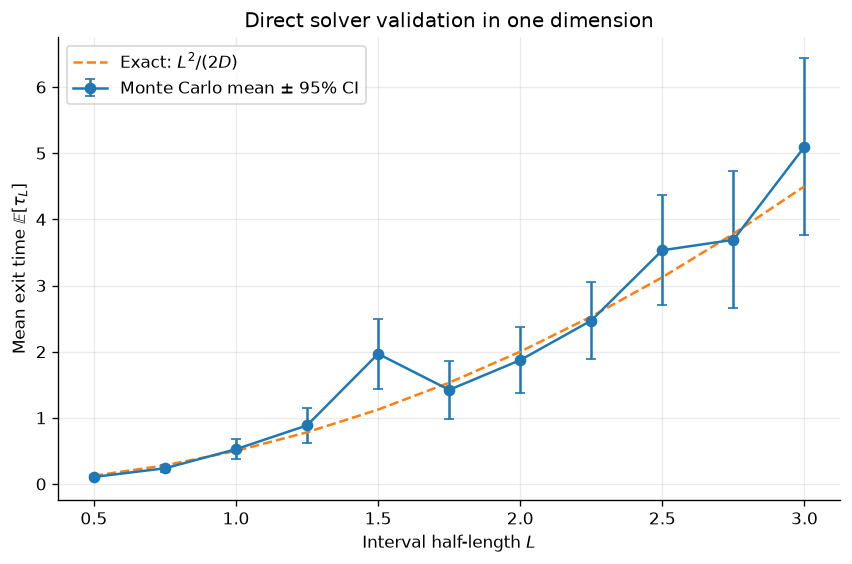

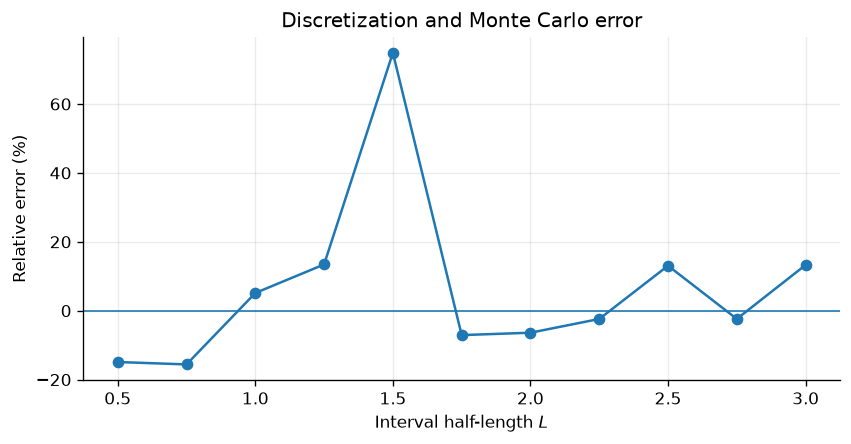

In [5]:
lengths = np.array([row["half_length"] for row in interval_summary])
means = np.array([row["mean"] for row in interval_summary])
cis = np.array([row["ci"] for row in interval_summary])
exact = lengths**2 / (2.0 * D)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.errorbar(lengths, means, yerr=cis, marker="o", capsize=3, label="Monte Carlo mean ± 95% CI")
ax.plot(lengths, exact, linestyle="--", label=r"Exact: $L^2/(2D)$")
ax.set(xlabel=r"Interval half-length $L$", ylabel=r"Mean exit time $\mathbb{E}[\tau_L]$")
ax.set_title("Direct solver validation in one dimension")
ax.legend()
fig.tight_layout()
save_figure(fig, "01_interval_validation.png")
plt.show()

relative_error = (means - exact) / exact
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.axhline(0.0, linewidth=1.0)
ax.plot(lengths, 100.0 * relative_error, marker="o")
ax.set(xlabel=r"Interval half-length $L$", ylabel="Relative error (%)")
ax.set_title("Discretization and Monte Carlo error")
fig.tight_layout()
save_figure(fig, "02_interval_relative_error.png")
plt.show()


## 2. Narrow escape in the unit disk

The absorbing window is restricted to the right-hand side of the circle:

$[
x>0, \qquad |y| \leq \epsilon/2.
]$

Adding the condition `x > 0` is essential: without it, the same vertical strip also creates a second window on the left side of the disk.


In [6]:
def unit_disk() -> Surface:
    return Surface("unit disk", [lambda point: point[0] ** 2 + point[1] ** 2 - 1.0])


def direct_window(epsilon: float) -> Escape:
    return Escape(
        [
            lambda point: point[0] > 0.0,
            lambda point, eps=epsilon: abs(point[1]) <= eps / 2.0,
        ]
    )


def simulate_disk_escape(epsilon: float, seed: int, keep_result: bool = False):
    motion = BrownianMotion(
        deposition_stride=DEPOSITION_STRIDE,
        delta_t=DELTA_T_2D,
        dimension=2,
        D=D,
        initial_position=np.zeros(2),
        seed=seed,
    )
    simulation = NaiveNarrowEscape(motion, unit_disk(), [direct_window(epsilon)])
    result = simulation.run(max_steps=MAX_STEPS_2D)
    if keep_result:
        return simulation, result
    return {
        "epsilon": float(epsilon),
        "seed": int(seed),
        "escaped": bool(result.escaped),
        "escape_time": None if result.escape_time is None else float(result.escape_time),
        "attempted_steps": int(result.attempted_steps),
        "rejection_fraction": float(result.rejected_steps / max(result.attempted_steps, 1)),
    }


def compute_disk_sweep() -> list[dict]:
    tasks = [(float(epsilon), replicate) for epsilon in EPSILONS for replicate in range(N_REPLICATES_2D)]
    seeds = spawned_seeds(BASE_SEED + 1, len(tasks))
    return Parallel(n_jobs=N_JOBS)(
        delayed(simulate_disk_escape)(epsilon, seed)
        for (epsilon, _), seed in zip(tasks, seeds, strict=True)
    )


disk_records = load_or_compute(
    CACHE_DIR / f"01_disk_direct_{PROFILE}.json",
    compute_disk_sweep,
)
disk_summary = summarize_records(disk_records, "epsilon")
print_summary(disk_summary, "epsilon")


     epsilon |       mean |     95% CI |   escaped |   reject.
--------------------------------------------------------------
        0.04 |     8.4094 |       2.17 |     32/32 |     0.025
     0.05485 |       8.75 |       2.95 |     32/32 |     0.025
    0.075212 |     6.1472 |        2.1 |     32/32 |     0.023
     0.10313 |     4.1698 |       1.59 |     32/32 |     0.022
     0.14142 |     4.5203 |        1.3 |     32/32 |     0.021
     0.19392 |     3.5082 |       1.36 |     32/32 |     0.022
     0.26591 |     3.4379 |       0.97 |     32/32 |     0.022
     0.36463 |     1.6883 |      0.516 |     32/32 |     0.019
         0.5 |     1.9523 |      0.643 |     32/32 |     0.021


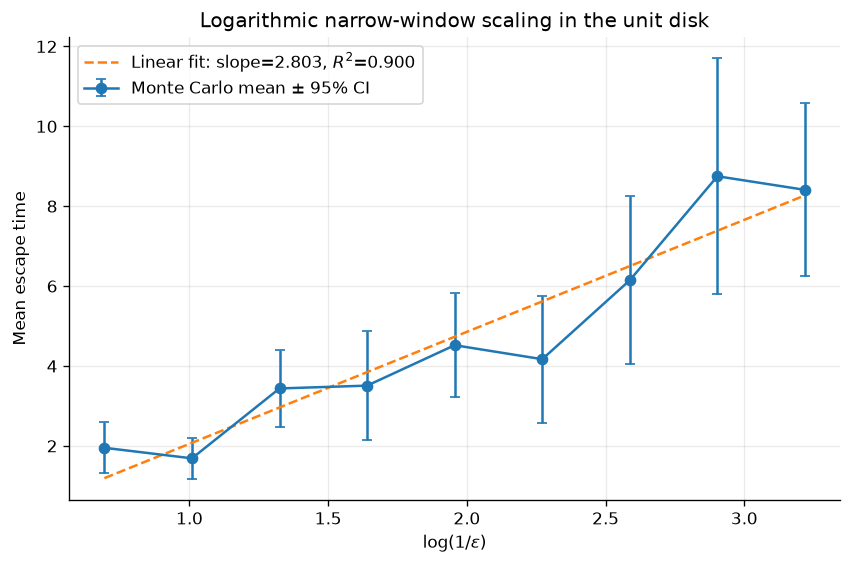

In [7]:
epsilon = np.array([row["epsilon"] for row in disk_summary])
mean_time = np.array([row["mean"] for row in disk_summary])
ci_time = np.array([row["ci"] for row in disk_summary])
escape_fraction = np.array([row["escape_fraction"] for row in disk_summary])

valid = np.isfinite(mean_time)
x = np.log(1.0 / epsilon[valid])
y = mean_time[valid]
slope, intercept = np.polyfit(x, y, deg=1)
y_fit = intercept + slope * x
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0.0 else np.nan

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.errorbar(
    np.log(1.0 / epsilon),
    mean_time,
    yerr=ci_time,
    marker="o",
    capsize=3,
    label="Monte Carlo mean ± 95% CI",
)
order = np.argsort(x)
ax.plot(
    x[order],
    y_fit[order],
    linestyle="--",
    label=rf"Linear fit: slope={slope:.3f}, $R^2$={r_squared:.3f}",
)
ax.set(xlabel=r"$\log(1/\epsilon)$", ylabel="Mean escape time")
ax.set_title("Logarithmic narrow-window scaling in the unit disk")
ax.legend()
fig.tight_layout()
save_figure(fig, "03_disk_logarithmic_scaling.png")
plt.show()

if np.any(escape_fraction < 1.0):
    print("Warning: at least one parameter value contains censored trajectories.")
    print(dict(zip(epsilon, escape_fraction, strict=True)))


## 3. Representative trajectory

The trajectory figure is intentionally generated from one explicit `NarrowEscapeResult`; no stored notebook output is required. The boundary is coloured according to whether each segment is reflective or absorbing.


{'epsilon': 0.1414213562373095, 'escaped': True, 'escape_time': 1.3827473729283242, 'attempted_steps': 2766, 'rejected_steps': 43}


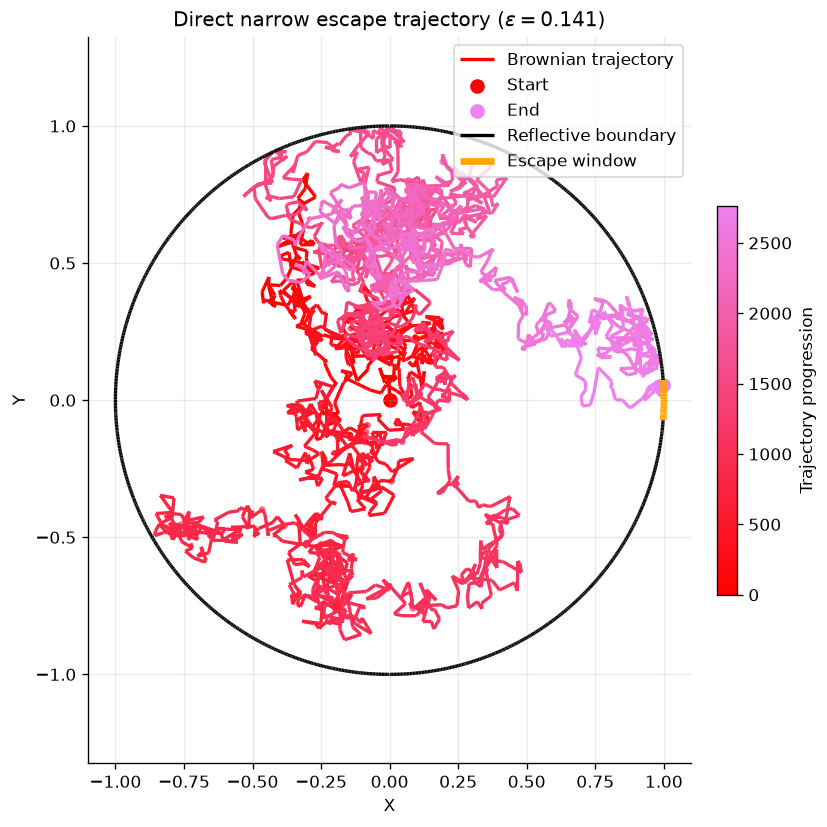

In [8]:
representative_epsilon = float(EPSILONS[len(EPSILONS) // 2])
representative_seed = spawned_seeds(BASE_SEED + 2, 1)[0]
representative_simulation, representative_result = simulate_disk_escape(
    representative_epsilon,
    representative_seed,
    keep_result=True,
)

print(
    {
        "epsilon": representative_epsilon,
        "escaped": representative_result.escaped,
        "escape_time": representative_result.escape_time,
        "attempted_steps": representative_result.attempted_steps,
        "rejected_steps": representative_result.rejected_steps,
    }
)

fig, ax = representative_simulation.plot_narrow_escape_problem(
    xlim=(-1.08, 1.08),
    ylim=(-1.08, 1.08),
    point_stride=max(representative_result.attempted_steps // 40, 1),
    point_size=16,
    point_alpha=0.65,
    show_points=True,
    show=False,
)
ax.set_title(rf"Direct narrow escape trajectory ($\epsilon={representative_epsilon:.3g}$)")
fig.tight_layout()
save_figure(fig, "04_representative_trajectory.png")
plt.show()


## Interpretation

- The one-dimensional curve should agree with `L²/(2D)` within sampling and time-discretization error. A systematic deviation that grows with `L` indicates that `max_steps` is too small; a nearly uniform bias points instead to `delta_t`.
- In two dimensions, the representative result is the approximately linear relationship between the mean escape time and `log(1/epsilon)`.
- The confidence interval is computed from independent trajectories. The raw standard deviation is not used as an uncertainty band.
- The escape fraction and rejection fraction remain visible diagnostics. A parameter point with substantial censoring should be rerun with a larger total step cap before it is interpreted.
